In [24]:
import pandas as pd
import numpy as np

In [25]:
data=pd.read_csv(r"/kaggle/input/datasets/lawrencekamande/mybnbs/bnb.csv")
data.columns


Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [4]:
data.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [3]:
print(data.groupby('room_type')['price'].mean().sort_values(ascending=False))
print()
print(data.groupby('neighbourhood')['price'].median().sort_values(ascending=False))

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

neighbourhood
Fort Wadsworth    800.0
Woodrow           700.0
Tribeca           295.0
Neponsit          274.0
NoHo              250.0
                  ...  
Corona             40.0
New Dorp Beach     40.0
Hunts Point        40.0
Castle Hill        39.0
Concord            34.5
Name: price, Length: 221, dtype: float64


In [4]:
import matplotlib.pylab as plt

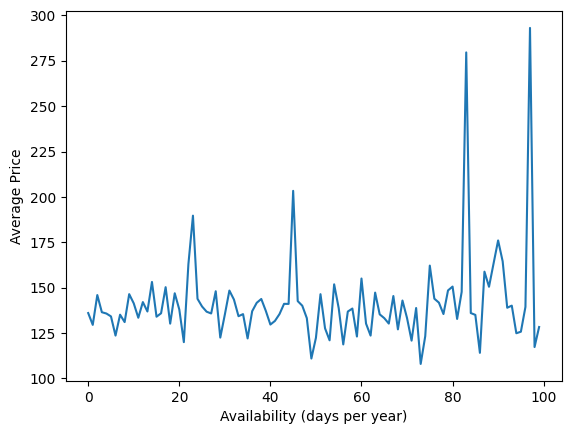

In [10]:
pdata=data.groupby('availability_365')['price'].mean().head(100)
avail=data['availability_365'].head(10)
price=data['price'].head(10)

# plt.plot(pdata)
plt.plot(pdata)
plt.xlabel('Availability (days per year)')
plt.ylabel('Average Price')
plt.show()

In [9]:
data['availability_365'].corr(data['price'])
data['number_of_reviews'].corr(data['price'])

data['availability_365'].corr(data['price'])
data['minimum_nights'].corr(data['price'])
data['number_of_reviews'].corr(data['price'])

np.float64(-0.047954226582662185)

Using location, room type as the main features ,

In [5]:
data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [14]:
data.groupby(['neighbourhood_group'])['price'].mean().sort_values(ascending=False)


neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error

In [43]:
encoded=pd.get_dummies(
    data[['room_type','neighbourhood_group','neighbourhood']],
    dtype=int
)

numerical = [
    'availability_365',
    'minimum_nights',
    'number_of_reviews',
    'calculated_host_listings_count'
]


In [44]:
X=pd.concat([encoded,data[numerical]],axis=1)
y=data['price']

In [45]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [46]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [47]:
prediction=model.predict(X_test)
prediction

array([157.26128264,  44.81489959, 125.71811118, ...,  46.62858632,
       215.30035384, 180.35783502])

In [48]:
mae=mean_absolute_error(y_test,prediction)
r2=r2_score(y_test,prediction)

print(f"Mae:{mae}")
print(f"R2:{r2}")

Mae:68.2021730661302
R2:0.13499440155367304
